# PRIMERA ETAPA: EDA general de Ventas


## 1. Preparación básica

In [62]:
# Importar librerías principales
import numpy as np
import pandas as pd

# Configurar visualización de tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Cargar el dataset

Se carga el archivo `df_ventas1.csv` directamente desde la carpeta `data/processed`.

In [121]:
# Cargar el archivo CSV
df_ventas = pd.read_csv("../data/processed/df_ventas1.csv")
df_ventas.head(5)

C:\Users\Esteban\AppData\Local\Temp\ipykernel_16460\2633966789.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ventas = pd.read_csv("../data/processed/df_ventas1.csv")


,periodo,cod_cliente,cod_material,des_familia,cod_grupo_precio,des_zona_venta,des_lista_precio_actual,mnt_descuento_estructural,mnt_descuento_estructural_actual,mnt_descuento_logistico,mnt_descuento_promocional,mnt_descuento_comercial,mnt_descuento,mnt_descuento_dex,mnt_comision_dex,mnt_desmedro,mnt_costo_venta,mnt_comision,mnt_gasto_exportacion,mnt_ppim,mnt_gasto_venta,mnt_resultado_inflacion,mnt_participacion,mnt_go_to_market,mnt_asesoria_tecnica,mnt_ppim_trade,mnt_cost_to_serve,des_cluster_canal,venta
0,2024-03-01,1000009499,SKU_0029,Original,B1,TACNA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,515.58
1,2024-03-01,1000009332,SKU_0045,Cuidado,B1,AYACUCHO,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,745.37
2,2024-03-01,1000009091,SKU_0037,Activa,B2,AREQUIPA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,-0.11,0,0,0.00,0.00,0.00,-0.11,-0.11,604.55
3,2024-03-01,1000009310,SKU_0045,Cuidado,B1,PIURA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,662.95
4,2024-03-01,1000009448,SKU_0015,Delicada,B1,JULIACA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,565.41


In [64]:
# Revisar dimensiones iniciales
filas, columnas = df_ventas.shape

print(f"Número de filas   : {filas:,}")
print(f"Número de columnas: {columnas}")

Número de filas   : 35,259
Número de columnas: 29


El dataset se cargó con 35,259 filas y 29 columnas. A partir de aquí se revisa si las columnas tienen nombres adecuados y si los tipos de datos fueron interpretados correctamente.

## 3. Revisar nombres de columnas

Se revisan los nombres originales de las columnas antes de hacer cualquier cambio. La idea es validar si están en minúscula, sin espacios, sin tildes y sin caracteres especiales.

In [65]:
# Listar columnas originales
columnas_originales = pd.DataFrame({
    "nro_columna": range(1, len(df_ventas.columns) + 1),
    "columna_original": df_ventas.columns,
})

columnas_originales

,nro_columna,columna_original
0,1,periodo
1,2,cod_cliente
2,3,cod_material
3,4,des_familia
4,5,cod_grupo_precio
5,6,des_zona_venta
6,7,des_lista_precio_actual
7,8,mnt_descuento_estructural
8,9,mnt_descuento_estructural_actual
9,10,mnt_descuento_logistico


Los nombres de columnas ya se observan en formato consistente: están en minúscula, usan guion bajo y no presentan espacios visibles. De todas formas, se aplica una validación formal para asegurar que los nombres queden estandarizados antes de continuar con el análisis.

## 4. Estandarizar nombres de columnas.

In [66]:
# Importar herramientas para estandarizar nombres de columnas
import re
import unicodedata

# Crear función para sugerir nombres estandarizados
def normalizar_nombre_columna(nombre):
    nombre = str(nombre).strip().lower()
    nombre = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode("ascii")
    nombre = re.sub(r"[^a-z0-9_]+", "_", nombre)
    nombre = re.sub(r"_+", "_", nombre).strip("_")
    return nombre

# Comparar nombre original vs. nombre sugerido
revision_columnas = pd.DataFrame({
    "columna_original": df_ventas.columns,
    "columna_sugerida": [normalizar_nombre_columna(col) for col in df_ventas.columns],
})

revision_columnas["requiere_cambio"] = (
    revision_columnas["columna_original"] != revision_columnas["columna_sugerida"]
)

revision_columnas["duplicada_al_normalizar"] = (
    revision_columnas["columna_sugerida"].duplicated(keep=False)
)

revision_columnas

,columna_original,columna_sugerida,requiere_cambio,duplicada_al_normalizar
0,periodo,periodo,False,False
1,cod_cliente,cod_cliente,False,False
2,cod_material,cod_material,False,False
3,des_familia,des_familia,False,False
4,cod_grupo_precio,cod_grupo_precio,False,False
5,des_zona_venta,des_zona_venta,False,False
6,des_lista_precio_actual,des_lista_precio_actual,False,False
7,mnt_descuento_estructural,mnt_descuento_estructural,False,False
8,mnt_descuento_estructural_actual,mnt_descuento_estructural_actual,False,False
9,mnt_descuento_logistico,mnt_descuento_logistico,False,False


In [67]:
# Aplicar renombrado solo si se encuentra algún problema
if revision_columnas["duplicada_al_normalizar"].any():
    print("Hay columnas que quedarían duplicadas al normalizar. Revisar manualmente antes de renombrar.")
elif revision_columnas["requiere_cambio"].any():
    mapa_columnas = dict(zip(
        revision_columnas["columna_original"],
        revision_columnas["columna_sugerida"],
    ))
    df_ventas = df_ventas.rename(columns=mapa_columnas)
    print("Se renombraron columnas para dejarlas en formato estándar.")
else:
    print("No se renombraron columnas: los nombres ya cumplen el formato esperado.")

No se renombraron columnas: los nombres ya cumplen el formato esperado.


## 5. Identificar unidad de análisis y granularidad

In [68]:
df_ventas.head()

,periodo,cod_cliente,cod_material,des_familia,cod_grupo_precio,des_zona_venta,des_lista_precio_actual,mnt_descuento_estructural,mnt_descuento_estructural_actual,mnt_descuento_logistico,mnt_descuento_promocional,mnt_descuento_comercial,mnt_descuento,mnt_descuento_dex,mnt_comision_dex,mnt_desmedro,mnt_costo_venta,mnt_comision,mnt_gasto_exportacion,mnt_ppim,mnt_gasto_venta,mnt_resultado_inflacion,mnt_participacion,mnt_go_to_market,mnt_asesoria_tecnica,mnt_ppim_trade,mnt_cost_to_serve,des_cluster_canal,venta
0,2024-03-01,1000009499,SKU_0029,Original,B1,TACNA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,515.58
1,2024-03-01,1000009332,SKU_0045,Cuidado,B1,AYACUCHO,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,745.37
2,2024-03-01,1000009091,SKU_0037,Activa,B2,AREQUIPA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,-0.11,0,0,0.00,0.00,0.00,-0.11,-0.11,604.55
3,2024-03-01,1000009310,SKU_0045,Cuidado,B1,PIURA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,662.95
4,2024-03-01,1000009448,SKU_0015,Delicada,B1,JULIACA,Minor,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,565.41


In [69]:
# Validar granularidad temporal

In [70]:
# Validar si existen filas exactamente duplicadas
df_ventas.duplicated().sum()

np.int64(0)

### Hallazgo sobre unidad de análisis y granularidad temporal

**Granularidad temporal:** La variable `periodo` está expresada a nivel mensual. Aunque aparece como una fecha con día 01, debe interpretarse como el mes correspondiente al registro. Por ejemplo, `2024-03-01` representa marzo de 2024 y no necesariamente una operación realizada el 1 de marzo.

**Unidad de análisis:** Cada fila se interpreta como un registro comercial mensual de ventas dentro de la información disponible. No se asume que la base esté a nivel de transacción, factura o compra individual, ya que no se cuenta con un identificador único de operación.

## 6. Revisar y corregir tipos de datos

In [71]:
# Revisar estructura inicial de tipos de datos
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35259 entries, 0 to 35258
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   periodo                           35259 non-null  object 
 1   cod_cliente                       35259 non-null  object 
 2   cod_material                      35259 non-null  object 
 3   des_familia                       35259 non-null  object 
 4   cod_grupo_precio                  35259 non-null  object 
 5   des_zona_venta                    35259 non-null  object 
 6   des_lista_precio_actual           35259 non-null  object 
 7   mnt_descuento_estructural         35259 non-null  int64  
 8   mnt_descuento_estructural_actual  35259 non-null  int64  
 9   mnt_descuento_logistico           35259 non-null  float64
 10  mnt_descuento_promocional         35259 non-null  float64
 11  mnt_descuento_comercial           35259 non-null  float64
 12  mnt_

In [72]:
# Convertir periodo a fecha
df_ventas["periodo"] = pd.to_datetime(df_ventas["periodo"], errors="coerce")

# Convertir todas las columnas object a string
columnas_object = df_ventas.select_dtypes(include="object").columns.tolist()
for col in columnas_object:
    df_ventas[col] = df_ventas[col].astype("string")

# Crear resumen de tipos luego de la conversión
resumen_tipos = pd.DataFrame({
    "columna": df_ventas.columns,
    "tipo_dato": df_ventas.dtypes.astype(str).values,
    "fue_object_convertido_a_string": df_ventas.columns.isin(columnas_object),
})

resumen_tipos

,columna,tipo_dato,fue_object_convertido_a_string
0,periodo,datetime64[ns],False
1,cod_cliente,string,True
2,cod_material,string,True
3,des_familia,string,True
4,cod_grupo_precio,string,True
5,des_zona_venta,string,True
6,des_lista_precio_actual,string,True
7,mnt_descuento_estructural,int64,False
8,mnt_descuento_estructural_actual,int64,False
9,mnt_descuento_logistico,float64,False


In [73]:
# Revisar si la conversión de periodo generó fechas nulas
revision_conversion_periodo = pd.DataFrame({
    "columna": ["periodo"],
    "nulos_despues_conversion": [df_ventas["periodo"].isna().sum()],
    "periodo_minimo": [df_ventas["periodo"].min()],
    "periodo_maximo": [df_ventas["periodo"].max()],
    "periodos_unicos": [df_ventas["periodo"].nunique()],
})

revision_conversion_periodo

,columna,nulos_despues_conversion,periodo_minimo,periodo_maximo,periodos_unicos
0,periodo,0,2024-01-01,2025-12-01,24


`periodo` quedó como fecha y no generó valores nulos al convertirlo. La cobertura temporal va de 2024-01-01 a 2025-12-01, con 24 periodos únicos.

Todas las columnas que pandas había interpretado como `object` fueron convertidas a `string`, incluyendo los identificadores y las variables categóricas.

## 7. Revisar y limpiar variables categóricas

Se revisaron las variables categóricas para asegurar que una misma categoría no esté fragmentada por diferencias de escritura (espacios al inicio o al final)

In [74]:
# Identificar columnas de texto después de corregir tipos
columnas_texto = df_ventas.select_dtypes(include=["object", "string"]).columns.tolist()
columnas_identificadoras = ["cod_cliente", "cod_material"]
columnas_categoricas = [
    col for col in columnas_texto
    if col not in columnas_identificadoras
]

# Revisar espacios y posible fragmentación por mayúsculas/minúsculas
revision_categorias = []
for col in columnas_texto:
    serie = df_ventas[col].dropna().astype("string")
    serie_limpia = serie.str.strip()
    revision_categorias.append({
        "columna": col,
        "tipo_variable": "identificador" if col in columnas_identificadoras else "categorica",
        "valores_unicos_original": serie.nunique(),
        "valores_unicos_sin_espacios": serie_limpia.nunique(),
        "valores_unicos_en_minuscula": serie_limpia.str.lower().nunique(),
        "filas_con_espacios_extremos": int((serie != serie_limpia).sum()),
    })

revision_categorias = pd.DataFrame(revision_categorias)
revision_categorias

,columna,tipo_variable,valores_unicos_original,valores_unicos_sin_espacios,valores_unicos_en_minuscula,filas_con_espacios_extremos
0,cod_cliente,identificador,140,140,140,0
1,cod_material,identificador,87,87,87,0
2,des_familia,categorica,8,8,8,0
3,cod_grupo_precio,categorica,3,3,3,0
4,des_zona_venta,categorica,29,29,29,0
5,des_lista_precio_actual,categorica,4,4,4,0


In [75]:
# Limpiar espacios al inicio y al final en columnas de texto
for col in columnas_texto:
    df_ventas[col] = df_ventas[col].astype("string").str.strip()

# Verificar limpieza aplicada
revision_categorias_post_limpieza = []
for col in columnas_texto:
    serie = df_ventas[col].dropna().astype("string")
    revision_categorias_post_limpieza.append({
        "columna": col,
        "tipo_variable": "identificador" if col in columnas_identificadoras else "categorica",
        "valores_unicos": serie.nunique(),
        "filas_con_espacios_extremos": int((serie != serie.str.strip()).sum()),
    })

pd.DataFrame(revision_categorias_post_limpieza)

,columna,tipo_variable,valores_unicos,filas_con_espacios_extremos
0,cod_cliente,identificador,140,0
1,cod_material,identificador,87,0
2,des_familia,categorica,8,0
3,cod_grupo_precio,categorica,3,0
4,des_zona_venta,categorica,29,0
5,des_lista_precio_actual,categorica,4,0


## 8. Revisar valores nulos

Después de corregir tipos y limpiar variables de texto, se revisan los valores nulos para saber si alguna columna requiere imputación, exclusión o validación adicional.

In [76]:
# Crear resumen de valores nulos por columna
resumen_nulos = pd.DataFrame({
    "columna": df_ventas.columns,
    "tipo_dato": df_ventas.dtypes.astype(str).values,
    "no_nulos": df_ventas.notna().sum().values,
    "nulos": df_ventas.isna().sum().values,
    "porcentaje_nulos": (df_ventas.isna().mean() * 100).round(2).values,
}).sort_values("nulos", ascending=False)

resumen_nulos

,columna,tipo_dato,no_nulos,nulos,porcentaje_nulos
0,periodo,datetime64[ns],35259,0,0.00
1,cod_cliente,string,35259,0,0.00
2,cod_material,string,35259,0,0.00
3,des_familia,string,35259,0,0.00
4,cod_grupo_precio,string,35259,0,0.00
5,des_zona_venta,string,35259,0,0.00
6,des_lista_precio_actual,string,35259,0,0.00
7,mnt_descuento_estructural,int64,35259,0,0.00
8,mnt_descuento_estructural_actual,int64,35259,0,0.00
9,mnt_descuento_logistico,float64,35259,0,0.00


### Hallazgo sobre nulos

No se identificaron valores nulos en el dataset después de las conversiones realizadas. Por ello, en esta etapa no se requiere imputar ni eliminar registros por datos faltantes.

## 9. Revisar duplicados

Luego de revisar nulos, se validan duplicados exactos y tambien repeticiones a nivel de `periodo`, `cod_cliente`, `des_familia` y `cod_material`. Esta segunda revision no implica eliminar filas; sirve para comprobar si esa combinacion comercial candidata puede identificar una observacion de forma unica.

In [77]:
# Revisar duplicados exactos y repeticiones en el nivel comercial candidato
columnas_nivel_comercial = ["periodo", "cod_cliente", "des_familia", "cod_material"]

revision_duplicados = pd.DataFrame({
    "revision": [
        "filas_totales",
        "duplicados_exactos",
        "combinaciones_unicas_periodo_cliente_familia_material",
        "filas_repetidas_en_nivel_comercial",
    ],
    "resultado": [
        len(df_ventas),
        df_ventas.duplicated().sum(),
        df_ventas[columnas_nivel_comercial].drop_duplicates().shape[0],
        df_ventas.duplicated(subset=columnas_nivel_comercial).sum(),
    ],
})

revision_duplicados

,revision,resultado
0,filas_totales,35259
1,duplicados_exactos,0
2,combinaciones_unicas_periodo_cliente_familia_m...,10988
3,filas_repetidas_en_nivel_comercial,24271


### Adicional: columnas que diferencian combinaciones repetidas

Para entender por que se repite la combinacion `periodo` + `cod_cliente` + `des_familia` + `cod_material`, se revisa que otras columnas cambian dentro de esas combinaciones repetidas.

In [78]:
# Analizar columnas que diferencian las combinaciones repetidas del nivel comercial
mascara_nivel_comercial_repetido = df_ventas.duplicated(
    subset=columnas_nivel_comercial,
    keep=False,
)

df_nivel_comercial_repetido = df_ventas.loc[mascara_nivel_comercial_repetido].copy()

columnas_comparacion_repetidos = [
    col for col in df_ventas.columns
    if col not in columnas_nivel_comercial
]

tamano_combinaciones_repetidas = (
    df_nivel_comercial_repetido
    .groupby(columnas_nivel_comercial, dropna=False)
    .size()
)

conteos_unicos_por_combinacion = (
    df_nivel_comercial_repetido
    .groupby(columnas_nivel_comercial, dropna=False)[columnas_comparacion_repetidos]
    .nunique(dropna=False)
)

resumen_repetidos_nivel_comercial = pd.DataFrame({
    "metrica": [
        "filas_en_combinaciones_repetidas",
        "combinaciones_repetidas",
        "max_filas_en_una_combinacion",
    ],
    "resultado": [
        int(mascara_nivel_comercial_repetido.sum()),
        int(len(tamano_combinaciones_repetidas)),
        int(tamano_combinaciones_repetidas.max()),
    ],
})

resumen_columnas_diferencian_repetidos = pd.DataFrame({
    "columna": columnas_comparacion_repetidos,
    "combinaciones_repetidas_con_diferencias": [
        int((conteos_unicos_por_combinacion[col] > 1).sum())
        for col in columnas_comparacion_repetidos
    ],
    "porcentaje_combinaciones_repetidas": [
        round(float((conteos_unicos_por_combinacion[col] > 1).mean() * 100), 2)
        for col in columnas_comparacion_repetidos
    ],
    "max_valores_distintos_en_una_combinacion": [
        int(conteos_unicos_por_combinacion[col].max())
        for col in columnas_comparacion_repetidos
    ],
}).sort_values(
    [
        "combinaciones_repetidas_con_diferencias",
        "max_valores_distintos_en_una_combinacion",
    ],
    ascending=False,
)

display(resumen_repetidos_nivel_comercial)
resumen_columnas_diferencian_repetidos

,metrica,resultado
0,filas_en_combinaciones_repetidas,31521
1,combinaciones_repetidas,7250
2,max_filas_en_una_combinacion,18


,columna,combinaciones_repetidas_con_diferencias,porcentaje_combinaciones_repetidas,max_valores_distintos_en_una_combinacion
24,venta,7250,100.00,18
16,mnt_gasto_venta,4652,64.17,9
22,mnt_cost_to_serve,4230,58.34,9
23,des_cluster_canal,4230,58.34,9
12,mnt_costo_venta,1281,17.67,5
1,des_zona_venta,177,2.44,2
10,mnt_comision_dex,131,1.81,2
2,des_lista_precio_actual,123,1.70,3
11,mnt_desmedro,114,1.57,2
9,mnt_descuento_dex,110,1.52,2


### Hallazgo sobre unicidad

No se encontraron filas duplicadas exactas. Sin embargo, la combinacion `periodo` + `cod_cliente` + `des_familia` + `cod_material` no es unica: existen varias filas para el mismo cliente, familia, SKU y mes.

Al analizar las combinaciones repetidas, se identifican 31,521 filas distribuidas en 7,250 combinaciones repetidas; la combinacion con mayor repeticion tiene 18 filas. La columna `venta` cambia en el 100.00% de esas combinaciones, por lo que es el principal valor que diferencia registros dentro del mismo nivel comercial.

Tambien se observan diferencias frecuentes en `mnt_gasto_venta` (64.17%), `mnt_cost_to_serve` (58.34%) y `des_cluster_canal` (58.34%). En menor medida cambian columnas como `mnt_costo_venta`, `des_zona_venta`, `mnt_comision_dex` y `des_lista_precio_actual`. En cambio, columnas como `mnt_descuento_estructural`, `mnt_descuento_estructural_actual`, `mnt_gasto_exportacion`, `mnt_resultado_inflacion` y `mnt_participacion` no ayudan a diferenciar estas repeticiones porque permanecen constantes dentro de cada combinacion repetida.

Por lo tanto, esa combinacion debe interpretarse como un nivel comercial de analisis y no como un identificador unico de observacion. Para identificar el evento transaccional que origina cada fila haria falta una columna adicional, como numero de factura, pedido, posicion o documento comercial.

## 10. Revisar estadística descriptiva inicial

Se realizó una primera revisión estadística de las variables numéricas para identificar valores típicos, dispersiones y posibles valores extremos.

In [79]:
# Seleccionar variables numéricas
columnas_numericas = df_ventas.select_dtypes(include="number").columns.tolist()

# Calcular estadística descriptiva inicial
estadistica_descriptiva_numerica = df_ventas[columnas_numericas].describe().T
estadistica_descriptiva_numerica["rango"] = (
    estadistica_descriptiva_numerica["max"] - estadistica_descriptiva_numerica["min"]
)

estadistica_descriptiva_numerica.sort_values("std", ascending=False)

,count,mean,std,min,25%,50%,75%,max,rango
mnt_costo_venta,35259.00,104.39,20972.09,-895876.76,0.00,0.00,0.00,3303567.62,4199444.38
mnt_go_to_market,35259.00,-51.68,1652.86,-153203.53,0.00,0.00,0.00,786.99,153990.52
venta,35259.00,718.77,572.33,156.66,526.30,592.80,675.14,5910.89,5754.23
mnt_comision_dex,35259.00,-4.72,386.97,-15560.83,0.00,0.00,0.00,60884.07,76444.90
mnt_descuento_dex,35259.00,-3.56,376.10,-14710.21,0.00,0.00,0.00,60884.07,75594.28
mnt_cost_to_serve,35259.00,-10.38,316.75,-25062.35,0.00,0.00,0.00,8668.99,33731.34
des_cluster_canal,35259.00,-10.38,316.75,-25062.35,0.00,0.00,0.00,8668.99,33731.34
mnt_descuento,35259.00,-2.81,186.31,-15248.97,0.00,0.00,0.00,18353.72,33602.69
mnt_descuento_promocional,35259.00,-2.82,184.61,-15152.28,0.00,0.00,0.00,18403.45,33555.73
mnt_ppim,35259.00,-0.12,44.58,-6738.21,0.00,0.00,0.00,4751.79,11490.00


### Revisión de variables monetarias, signos y columnas constantes

**Diccionario breve de variables monetarias:**

- `mnt_descuento_estructural`: monto asociado al descuento estructural. En este dataset aparece siempre en cero.
- `mnt_descuento_estructural_actual`: monto del descuento estructural vigente o actual. En este dataset aparece siempre en cero.
- `mnt_descuento_logistico`: monto de descuento o ajuste relacionado con aspectos logisticos de la venta.
- `mnt_descuento_promocional`: monto de descuento asociado a promociones comerciales.
- `mnt_descuento_comercial`: monto de descuento comercial aplicado a la venta.
- `mnt_descuento`: monto total de descuentos aplicados en el registro.
- `mnt_descuento_dex`: monto de descuento asociado a DEX o concepto comercial interno. El significado exacto depende de la empresa.
- `mnt_comision_dex`: monto de comision asociado a DEX o al esquema comercial correspondiente.
- `mnt_desmedro`: monto asociado a perdidas, deterioros, mermas o desmedros del producto.
- `mnt_costo_venta`: costo de venta asociado al registro. Representa el costo de los productos vendidos.
- `mnt_comision`: monto de comision asociado a la venta.
- `mnt_gasto_exportacion`: gasto de exportacion asociado al registro. En este dataset aparece siempre en cero.
- `mnt_ppim`: monto asociado al concepto PPIM. Es una variable monetaria interna de la empresa.
- `mnt_gasto_venta`: monto de gastos de venta asociados al registro.
- `mnt_resultado_inflacion`: monto asociado al efecto o resultado por inflacion. En este dataset aparece siempre en cero.
- `mnt_participacion`: monto asociado a participacion u otro concepto comercial interno. En este dataset aparece siempre en cero.
- `mnt_go_to_market`: monto asociado a actividades comerciales de Go to Market, es decir, costos o ajustes vinculados a las acciones que realiza la empresa para colocar, impulsar y vender el producto a traves de sus distribuidoras o canales comerciales.
- `mnt_asesoria_tecnica`: monto asociado a asesoria tecnica u otros servicios relacionados con la venta.
- `mnt_ppim_trade`: monto asociado al concepto PPIM Trade. Es una variable monetaria comercial interna.
- `mnt_cost_to_serve`: monto del costo de servir o atender a la distribuidora. Puede incluir costos logisticos, comerciales u operativos asociados al servicio.
- `venta`: monto de venta registrado para la combinacion de periodo, distribuidora y producto/material.

>Varias variables `mnt_` pueden tener minimos negativos porque probablemente representan costos, descuentos, comisiones, gastos, ajustes o deducciones contables.

>Las columnas constantes en cero son: `mnt_descuento_estructural`, `mnt_descuento_estructural_actual`, `mnt_gasto_exportacion`, `mnt_resultado_inflacion` y `mnt_participacion`.

Estas columnas no aportan variabilidad al analisis actual, porque tienen el mismo valor en todas las filas. Por ello, se mantienen documentadas, pero no se consideran variables informativas para explicar diferencias de venta ni para posibles modelos posteriores.

**Advertencia metodologica:** La interpretacion de los signos negativos debe validarse con la fuente de datos o diccionario de negocio, ya que podrian responder a convenciones contables de la base.

### Hallazgos descriptivos iniciales

La variable `venta` tiene un promedio aproximado de 718.77, una mediana de 592.80 y un máximo de 5,910.89, por lo que existen registros de venta bastante por encima del valor típico.

Varias variables monetarias tienen mediana igual a 0, lo que indica que en muchos registros no se aplican esos conceptos. `mnt_costo_venta` presenta una dispersión alta y valores extremos, con mínimo negativo y máximo superior a 3 millones.

También se detectan columnas constantes: `mnt_descuento_estructural`, `mnt_descuento_estructural_actual`, `mnt_gasto_exportacion`, `mnt_resultado_inflacion` y `mnt_participacion`. Además, `des_cluster_canal` aparece como numérica y sus valores son iguales a `mnt_cost_to_serve`, por lo que conviene validarla con la fuente de datos antes de usarla.

## 11. Revisar el comportamiento general de ventas

Se analiza `venta` como KPI principal del proyecto. En esta primera revisión se calcula el monto vendido acumulado, el valor típico por registro, la dispersión y los principales percentiles.


In [80]:
# Resumen estadístico específico del KPI venta
venta = df_ventas["venta"]

resumen_venta = pd.DataFrame({
    "metrica": [
        "registros",
        "venta_acumulada",
        "venta_promedio_por_registro",
        "venta_mediana_por_registro",
        "desviacion_estandar",
        "coeficiente_variacion",
        "venta_minima",
        "percentil_25",
        "percentil_75",
        "percentil_90",
        "percentil_95",
        "percentil_99",
        "venta_maxima",
    ],
    "valor": [
        venta.count(),
        venta.sum(),
        venta.mean(),
        venta.median(),
        venta.std(),
        venta.std() / venta.mean(),
        venta.min(),
        venta.quantile(0.25),
        venta.quantile(0.75),
        venta.quantile(0.90),
        venta.quantile(0.95),
        venta.quantile(0.99),
        venta.max(),
    ],
})

resumen_venta


,metrica,valor
0,registros,35259.00
1,venta_acumulada,25343013.15
2,venta_promedio_por_registro,718.77
3,venta_mediana_por_registro,592.80
4,desviacion_estandar,572.33
5,coeficiente_variacion,0.80
6,venta_minima,156.66
7,percentil_25,526.30
8,percentil_75,675.14
9,percentil_90,776.64


### Hallazgo

La venta acumulada del periodo analizado es **25,343,013.15**. Este monto corresponde a ventas registradas, no a utilidad. La venta promedio por registro es **718.77** y la mediana es **592.80**, por lo que el promedio está siendo elevado por registros de venta más alta.


## 12. Revisar la distribución de ventas

Se grafica la distribución de `venta` con un histograma para observar si la mayoría de registros se concentra en ventas bajas o medias, y si existe una cola hacia la derecha.


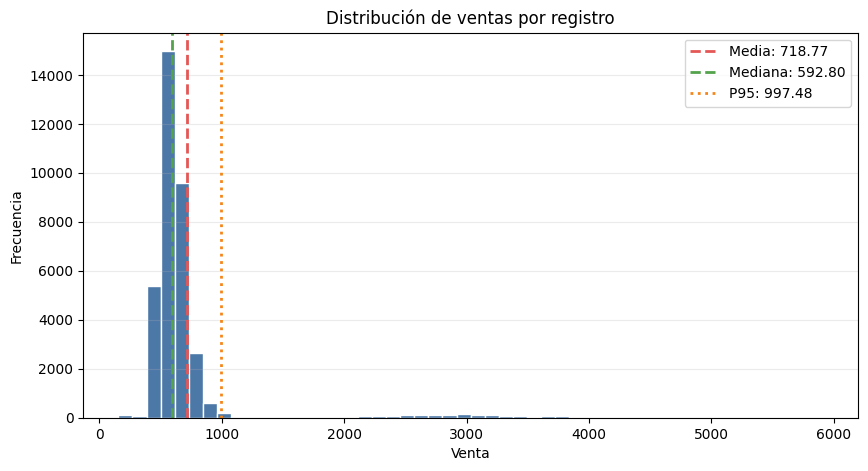

In [81]:
# Histograma de la distribución de ventas
import matplotlib.pyplot as plt

media_venta = venta.mean()
mediana_venta = venta.median()
p95_venta = venta.quantile(0.95)
p99_venta = venta.quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(venta, bins=50, color="#4C78A8", edgecolor="white")
ax.axvline(media_venta, color="#E45756", linestyle="--", linewidth=2, label=f"Media: {media_venta:,.2f}")
ax.axvline(mediana_venta, color="#54A24B", linestyle="--", linewidth=2, label=f"Mediana: {mediana_venta:,.2f}")
ax.axvline(p95_venta, color="#F58518", linestyle=":", linewidth=2, label=f"P95: {p95_venta:,.2f}")

ax.set_title("Distribución de ventas por registro")
ax.set_xlabel("Venta")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()


In [82]:
# Indicadores para interpretar la distribución
resumen_distribucion_venta = pd.DataFrame({
    "indicador": [
        "asimetria",
        "media",
        "mediana",
        "percentil_75",
        "percentil_90",
        "percentil_95",
        "percentil_99",
        "maximo",
    ],
    "valor": [
        venta.skew(),
        venta.mean(),
        venta.median(),
        venta.quantile(0.75),
        venta.quantile(0.90),
        venta.quantile(0.95),
        venta.quantile(0.99),
        venta.max(),
    ],
})

resumen_distribucion_venta


,indicador,valor
0,asimetria,4.66
1,media,718.77
2,mediana,592.80
3,percentil_75,675.14
4,percentil_90,776.64
5,percentil_95,997.48
6,percentil_99,3691.29
7,maximo,5910.89


### Hallazgo relevante

La distribución presenta **cola hacia la derecha (los valores muy altos jalan a la media)**. La asimetría es **4.66**, la media (**718.77**) es mayor que la mediana (**592.80**) y el 75% de los registros tiene ventas de hasta **675.14**. Esto indica que la mayoría de registros se concentra en ventas bajas o medias, mientras pocos registros altos estiran la distribución.


## 13. Identificar ventas altas y posibles outliers

Después de revisar la distribución, se aplica la regla de Tukey usando el rango intercuartílico. El objetivo es marcar ventas altas o posibles outliers para análisis posterior. En esta etapa **no se elimina ningún registro**.


In [83]:
# Identificar ventas altas usando rango intercuartílico / prueba de Tukey
q1 = venta.quantile(0.25)
q3 = venta.quantile(0.75)
iqr = q3 - q1
limite_inferior_venta = q1 - 1.5 * iqr
limite_superior_venta = q3 + 1.5 * iqr

ventas_altas = df_ventas[df_ventas["venta"] > limite_superior_venta].copy()

resumen_tukey_venta = pd.DataFrame({
    "metrica": [
        "q1",
        "q3",
        "iqr",
        "limite_inferior_tukey",
        "limite_superior_tukey",
        "registros_sobre_limite_superior",
        "porcentaje_registros_sobre_limite",
        "venta_acumulada_sobre_limite",
        "%participacion_venta_sobre_limite",
    ],
    "valor": [
        q1,
        q3,
        iqr,
        limite_inferior_venta,
        limite_superior_venta,
        len(ventas_altas),
        len(ventas_altas) / len(df_ventas) * 100,
        ventas_altas["venta"].sum(),
        ventas_altas["venta"].sum() / df_ventas["venta"].sum() * 100,
    ],
})

resumen_tukey_venta


,metrica,valor
0,q1,526.30
1,q3,675.14
2,iqr,148.84
3,limite_inferior_tukey,303.04
4,limite_superior_tukey,898.40
5,registros_sobre_limite_superior,2138.00
6,porcentaje_registros_sobre_limite,6.06
7,venta_acumulada_sobre_limite,5673236.75
8,%participacion_venta_sobre_limite,22.39


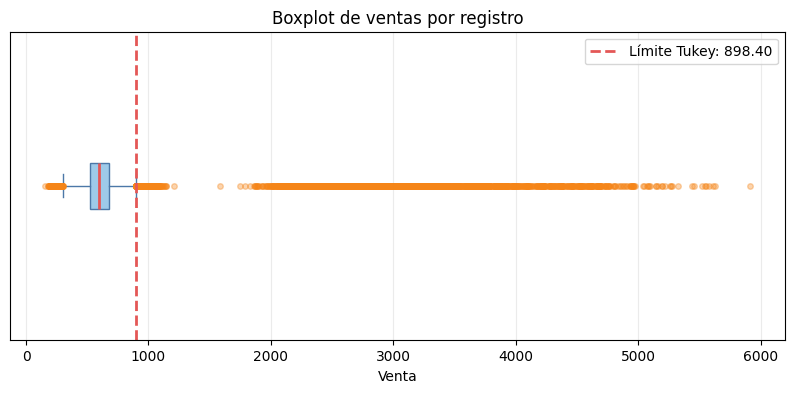

In [84]:
# Boxplot para visualizar ventas altas y posibles outliers
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    venta,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#9ECAE9", "color": "#4C78A8"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#4C78A8"},
    capprops={"color": "#4C78A8"},
    flierprops={"marker": "o", "markerfacecolor": "#F58518", "markeredgecolor": "#F58518", "alpha": 0.35, "markersize": 4},
)
ax.axvline(limite_superior_venta, color="#E45756", linestyle="--", linewidth=2, label=f"Límite Tukey: {limite_superior_venta:,.2f}")
ax.set_title("Boxplot de ventas por registro")
ax.set_xlabel("Venta")
ax.set_yticks([])
ax.legend()
ax.grid(axis="x", alpha=0.25)
plt.show()

Cada punto naranja representa un registro comercial cuyo monto de ventas está por encima del rango típico. La posición del punto en el eje X indica el valor de ventas de ese registro. Por ejemplo, un punto cercano a 5910 indica que existe un registro comercial con ventas cercanas a 5910

### Hallazgo relevante

El límite superior de Tukey es **898.40**. Hay **2,138 registros** por encima de ese umbral, equivalentes al **6.06%** de las filas, pero concentran **22.39%** de la venta acumulada. Se consideran ventas altas o posibles outliers comerciales; no se eliminan porque pueden representar operaciones relevantes.


## 14. Revisar evolución mensual de ventas

Luego de revisar la distribución y las ventas altas, se agregan las ventas por mes para evaluar si las ventas aumentan o disminuyen entre 2024 y 2025, identificar picos, caídas fuertes y periodos de mayor volatilidad.


In [85]:
# Evolución mensual de ventas
ventas_mensuales = (
    df_ventas
    .groupby("periodo", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        registros=("venta", "size"),
        venta_promedio_por_registro=("venta", "mean"),
        clientes_unicos=("cod_cliente", "nunique"),
        materiales_unicos=("cod_material", "nunique"),
    )
    .sort_values("periodo")
)

ventas_mensuales["variacion_mensual_abs"] = ventas_mensuales["venta_acumulada"].diff()
ventas_mensuales["variacion_mensual_pct"] = ventas_mensuales["venta_acumulada"].pct_change() * 100
ventas_mensuales["venta_media_movil_3m"] = ventas_mensuales["venta_acumulada"].rolling(3).mean()

ventas_mensuales


,periodo,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,variacion_mensual_abs,variacion_mensual_pct,venta_media_movil_3m
0,2024-01-01,786667.70,979,803.54,59,34,NaN,NaN,NaN
1,2024-02-01,1486843.44,1731,858.95,56,35,700175.74,89.01,NaN
2,2024-03-01,1617859.55,2101,770.04,53,26,131016.11,8.81,1297123.56
3,2024-04-01,2011401.45,1783,1128.10,55,36,393541.90,24.32,1705368.15
4,2024-05-01,1647202.85,1590,1035.98,55,41,-364198.60,-18.11,1758821.28
5,2024-06-01,2015135.51,2531,796.18,54,40,367932.66,22.34,1891246.60
6,2024-07-01,1573387.49,2141,734.88,82,43,-441748.02,-21.92,1745241.95
7,2024-08-01,455492.53,658,692.24,61,39,-1117894.96,-71.05,1348005.18
8,2024-09-01,2236325.15,3144,711.30,63,47,1780832.62,390.97,1421735.06
9,2024-10-01,752540.74,1113,676.14,55,36,-1483784.41,-66.35,1148119.47


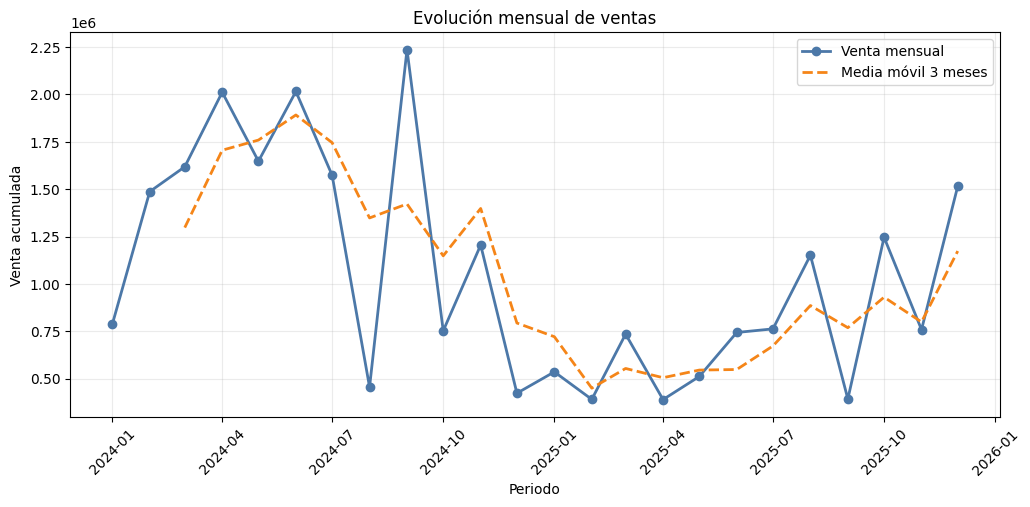

In [86]:
# Gráfico de línea para la evolución mensual de ventas
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    ventas_mensuales["periodo"],
    ventas_mensuales["venta_acumulada"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Venta mensual",
)
ax.plot(
    ventas_mensuales["periodo"],
    ventas_mensuales["venta_media_movil_3m"],
    linewidth=2,
    linestyle="--",
    color="#F58518",
    label="Media móvil 3 meses",
)

ax.set_title("Evolución mensual de ventas")
ax.set_xlabel("Periodo")
ax.set_ylabel("Venta acumulada")
ax.legend()
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.show()


### Hallazgo relevante

El mayor pico mensual ocurre en **septiembre de 2024**, con **2,236,325.15**. El menor nivel mensual ocurre en **abril de 2025**, con **389,602.61**. La caída más fuerte se observa de septiembre a octubre de 2024, con **-1,483,784.41** (**-66.35%**), por lo que hay meses con alta volatilidad que deben revisarse antes de explicar la caída anual.


## 15. Comparar ventas por año

Se compara el desempeño anual para cuantificar la diferencia entre 2024 y 2025 en venta acumulada, registros, clientes únicos y materiales únicos.


In [87]:
# Comparación anual de ventas
ventas_por_anio = (
    df_ventas
    .assign(año=df_ventas["periodo"].dt.year)
    .groupby("año", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        registros=("venta", "size"),
        venta_promedio_por_registro=("venta", "mean"),
        clientes_unicos=("cod_cliente", "nunique"),
        materiales_unicos=("cod_material", "nunique"),
    )
)

ventas_por_anio["variacion_anual_abs"] = ventas_por_anio["venta_acumulada"].diff()
ventas_por_anio["variacion_anual_pct"] = ventas_por_anio["venta_acumulada"].pct_change() * 100

ventas_por_anio


,año,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,variacion_anual_abs,variacion_anual_pct
0,2024,16210991.47,20158,804.20,112,67,NaN,NaN
1,2025,9132021.68,15101,604.73,82,70,-7078969.79,-43.67


### Hallazgos relevante

-Las ventas pasan de **16,210,991.47** en 2024 a **9,132,021.68** en 2025. La variacion anual es de **-7,078,969.79**, equivalente a una caida de **-43.67%**. Esta es la principal senal comercial a explicar en los siguientes analisis.

-La caida no se explica solo por una menor cantidad de registros: los registros bajan de **20,158** en 2024 a **15,101** en 2025, mientras que la venta promedio por registro tambien disminuye de **804.20** a **604.73**. Es decir, en 2025 hubo menos registros y, ademas, cada registro vendio menos en promedio.

-Tambien se observa una reduccion de clientes activos o registrados en la base de ventas: los clientes unicos pasan de **112** en 2024 a **82** en 2025. En contraste, los materiales unicos aumentan ligeramente de **67** a **70**, por lo que la contraccion parece estar mas asociada a menor actividad comercial y menor ticket promedio por registro que a una reduccion del portafolio observado.

## 16. Revisar ventas por familia

Se agrupan las ventas por `des_familia` para identificar que categorias principales de producto concentran mayor peso en el KPI.


In [88]:
# Función para resumir ventas por dimensión comercial
def resumir_ventas_por_dimension(df, dimension, top=10):
    resumen = (
        df
        .groupby(dimension, as_index=False)
        .agg(
            venta_acumulada=("venta", "sum"),
            registros=("venta", "size"),
            venta_promedio_por_registro=("venta", "mean"),
            clientes_unicos=("cod_cliente", "nunique"),
            materiales_unicos=("cod_material", "nunique"),
        )
        .sort_values("venta_acumulada", ascending=False)
    )
    resumen["participacion_venta_pct"] = resumen["venta_acumulada"] / resumen["venta_acumulada"].sum() * 100
    resumen["participacion_acumulada_pct"] = resumen["participacion_venta_pct"].cumsum()
    return resumen.head(top)

ventas_por_familia = resumir_ventas_por_dimension(df_ventas, "des_familia", top=20)
ventas_por_familia


,des_familia,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
5,Frescura,10115913.22,14063,719.33,83,15,39.92,39.92
4,Delicada,6233424.52,8625,722.72,82,14,24.60,64.51
3,Cuidado,5551681.67,8305,668.47,76,9,21.91,86.42
6,Original,1545218.79,2076,744.33,118,33,6.10,92.52
0,Activa,1477837.80,1664,888.12,57,9,5.83,98.35
1,Avance,239918.79,296,810.54,39,12,0.95,99.29
7,Vital,166567.65,213,782.01,33,5,0.66,99.95
2,Confort,12450.71,17,732.39,14,1,0.05,100.00


### Hallazgo relevante

`Frescura` es la familia más importante, con **10,115,913.22** en ventas y **39.92%** de participación. Junto con `Delicada` y `Cuidado`, concentra aproximadamente **86.42%** de la venta acumulada.


## 17. Revisar ventas por zona

Se agrupan las ventas por `des_zona_venta` para identificar las zonas comerciales con mayor aporte.


In [89]:
# Principales zonas por venta
ventas_por_zona = resumir_ventas_por_dimension(df_ventas, "des_zona_venta", top=15)
ventas_por_zona


,des_zona_venta,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
8,CUSCO,4023296.48,2860,1406.75,13,49,15.88,15.88
16,LIMA,3728320.78,5850,637.32,30,63,14.71,30.59
2,AREQUIPA,1879109.10,2989,628.67,14,52,7.41,38.00
5,CHICLAYO,1356783.16,1685,805.21,10,45,5.35,43.36
24,TACNA,1300043.25,2008,647.43,10,44,5.13,48.48
12,HUANUCO,1183742.84,1260,939.48,9,47,4.67,53.16
25,TARAPOTO,1123476.68,1616,695.22,6,46,4.43,57.59
27,TRUJILLO,1106061.07,1349,819.91,8,45,4.36,61.95
26,TARMA,942375.42,1625,579.92,6,51,3.72,65.67
14,ICA,769515.49,1365,563.75,8,43,3.04,68.71


### Hallazgo relevante

Las zonas con mayor venta son `CUSCO` y `LIMA`, con **15.88%** y **14.71%** de participación respectivamente. Ambas zonas concentran cerca de **30.59%** de la venta acumulada.


## 18. Revisar ventas por cliente

Se agrupan las ventas por `cod_cliente` para detectar clientes con alta concentración comercial.


In [90]:
# Principales clientes por venta
ventas_por_cliente = resumir_ventas_por_dimension(df_ventas, "cod_cliente", top=15)
ventas_por_cliente


,cod_cliente,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
82,1000009492,1721504.36,520,3310.59,1,34,6.79,6.79
45,1000005292,1125368.85,351,3206.18,1,32,4.44,11.23
83,1000009493,742001.27,1201,617.82,1,47,2.93,14.16
72,1000009332,707930.46,996,710.77,1,38,2.79,16.95
67,1000009091,633580.76,784,808.14,1,43,2.50,19.45
63,1000009052,621830.80,211,2947.07,1,19,2.45,21.91
80,1000009451,611518.08,900,679.46,1,41,2.41,24.32
65,1000009069,603804.43,851,709.52,1,44,2.38,26.70
75,1000009385,590158.30,907,650.67,1,44,2.33,29.03
78,1000009434,569679.46,876,650.32,1,40,2.25,31.28


### Hallazgo relevante

El cliente con mayor venta es `1000009492`, con **1,721,504.36**, equivalente a **6.79%** de la venta acumulada. La concentración por cliente existe, pero no depende de un solo cliente.


## 19. Revisar ventas por SKU (producto)

Se agrupan las ventas por `des_familia` y `cod_material` para identificar los SKUs con mayor peso dentro del KPI.


In [91]:
# Principales SKUs/materiales por venta
ventas_por_material = resumir_ventas_por_dimension(df_ventas, ["des_familia", "cod_material"], top=15)
ventas_por_material


,des_familia,cod_material,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
55,Frescura,SKU_0060,2638362.57,3996,660.25,72,1,10.41,10.41
36,Delicada,SKU_0062,1810419.47,2674,677.05,62,1,7.14,17.55
28,Cuidado,SKU_0059,1740479.38,2839,613.06,60,1,6.87,24.42
56,Frescura,SKU_0061,1626719.12,2465,659.93,68,1,6.42,30.84
34,Delicada,SKU_0052,1513919.90,2310,655.38,64,1,5.97,36.81
27,Cuidado,SKU_0057,1419824.79,2216,640.72,55,1,5.60,42.42
54,Frescura,SKU_0055,1305672.02,1882,693.77,57,1,5.15,47.57
50,Frescura,SKU_0026,1247823.39,1432,871.39,54,1,4.92,52.49
53,Frescura,SKU_0054,1239897.23,1828,678.28,53,1,4.89,57.39
7,Activa,SKU_0041,1096421.79,1254,874.34,54,1,4.33,61.71


### Hallazgo

El SKU con mayor venta es `SKU_0060` de `Frescura`, con **2,638,362.57** y **10.41%** de participación. Esto refuerza que `Frescura` debe priorizarse en el análisis posterior.


## 20. Revisar variación de ventas por familia entre 2024 y 2025

Se compara cada familia entre ambos años para identificar qué líneas explican la caída anual observada.


In [92]:
# Familias que explican la variación entre 2024 y 2025
ventas_familia_anio = (
    df_ventas
    .assign(anio=df_ventas["periodo"].dt.year)
    .pivot_table(
        index="des_familia",
        columns="anio",
        values="venta",
        aggfunc="sum",
        fill_value=0,
    )
)

ventas_familia_anio["venta_acumulada"] = ventas_familia_anio.sum(axis=1)
ventas_familia_anio["variacion_2025_vs_2024_abs"] = ventas_familia_anio.get(2025, 0) - ventas_familia_anio.get(2024, 0)
ventas_familia_anio["variacion_2025_vs_2024_pct"] = (
    ventas_familia_anio["variacion_2025_vs_2024_abs"] / ventas_familia_anio.get(2024, 0) * 100
)

ventas_familia_anio.sort_values("variacion_2025_vs_2024_abs")


anio,2024,2025,venta_acumulada,variacion_2025_vs_2024_abs,variacion_2025_vs_2024_pct
des_familia,,,,,
Frescura,6597480.45,3518432.77,10115913.22,-3079047.68,-46.67
Activa,1469512.65,8325.15,1477837.80,-1461187.50,-99.43
Delicada,3828283.46,2405141.06,6233424.52,-1423142.40,-37.17
Original,1026210.85,519007.94,1545218.79,-507202.91,-49.42
Cuidado,2895336.60,2656345.07,5551681.67,-238991.53,-8.25
Avance,216841.97,23076.82,239918.79,-193765.15,-89.36
Vital,164874.78,1692.87,166567.65,-163181.91,-98.97
Confort,12450.71,0.00,12450.71,-12450.71,-100.00


### Hallazgo relevante

La mayor caída absoluta está en `Frescura`, con **-3,079,047.68** frente a 2024. Le siguen `Activa` con **-1,461,187.50** y `Delicada` con **-1,423,142.40**. Por impacto comercial, `Frescura` queda como la familia prioritaria para profundizar.


## 21. Revisar ventas por grupo de precio

Se agrupan las ventas por `cod_grupo_precio` para evaluar que segmentos comerciales de precio concentran mayor volumen de venta, registros, clientes y productos/SKUs.

In [93]:
# Ventas por grupo de precio
ventas_por_grupo_precio = resumir_ventas_por_dimension(df_ventas, "cod_grupo_precio", top=10)
ventas_por_grupo_precio


,cod_grupo_precio,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
0,B1,19837833.12,33090,599.51,128,81,78.28,78.28
1,B2,5502607.72,2166,2540.45,26,51,21.71,99.99
2,B9,2572.31,3,857.44,1,2,0.01,100.00


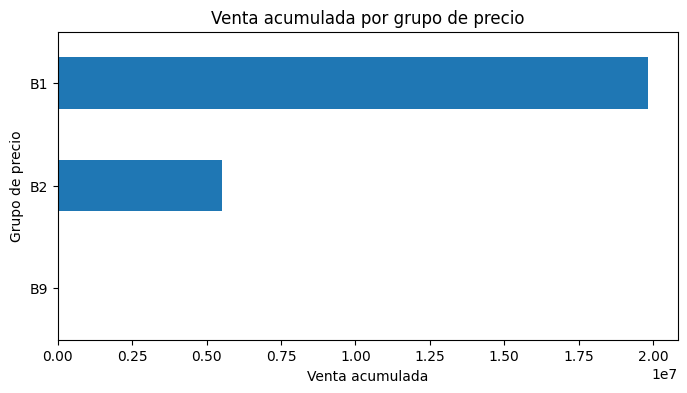

In [94]:
# Grafico de ventas por grupo de precio
fig, ax = plt.subplots(figsize=(8, 4))
ventas_por_grupo_precio.sort_values("venta_acumulada").plot(
    x="cod_grupo_precio",
    y="venta_acumulada",
    kind="barh",
    ax=ax,
    legend=False,
)
ax.set_title("Venta acumulada por grupo de precio")
ax.set_xlabel("Venta acumulada")
ax.set_ylabel("Grupo de precio")
plt.show()


- `B1`: grupo de precio de volumen, porque concentra la mayor venta acumulada y la mayor cantidad de registros.
- `B2`: grupo de precio de alto valor promedio, porque tiene menor cantidad de registros, pero una venta promedio por registro considerablemente más alta.
- `B9`: grupo residual o atípico, porque tiene muy pocos registros y participación mínima en ventas.

## 22. Revisar ventas por lista de precio / canal

Se usa `des_lista_precio_actual` como aproximacion comercial a lista de precio o canal aplicado al registro. No se usa `des_cluster_canal` como variable de canal porque en la revision descriptiva aparece con valores numericos iguales a `mnt_cost_to_serve`, por lo que requiere validacion con la fuente.

In [95]:
# Ventas por lista de precio actual
ventas_por_lista_precio = resumir_ventas_por_dimension(df_ventas, "des_lista_precio_actual", top=10)
ventas_por_lista_precio


,des_lista_precio_actual,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
2,Minor,20097028.10,33436,601.06,117,83,79.30,79.30
1,Mayor,5200655.90,1648,3155.74,25,47,20.52,99.82
3,Sin Asignar,42756.84,172,248.59,70,33,0.17,99.99
0,E-Commerce,2572.31,3,857.44,1,2,0.01,100.00


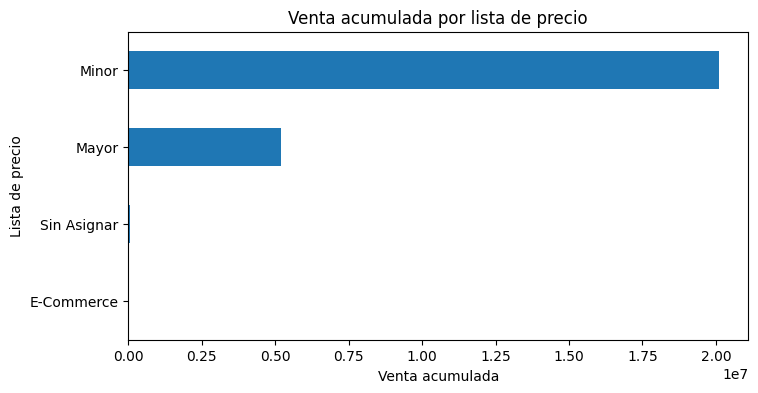

In [96]:
# Grafico de ventas por lista de precio actual
fig, ax = plt.subplots(figsize=(8, 4))
ventas_por_lista_precio.sort_values("venta_acumulada").plot(
    x="des_lista_precio_actual",
    y="venta_acumulada",
    kind="barh",
    ax=ax,
    legend=False,
)
ax.set_title("Venta acumulada por lista de precio")
ax.set_xlabel("Venta acumulada")
ax.set_ylabel("Lista de precio")
plt.show()


Minor: lista de precio minorista
<br>
Mayor: lista de precio mayorista

### Hallazgo

La lista `Minor` concentra **20,097,028.10** de venta acumulada, equivalente a **79.30%** del total, y tambien concentra la mayor cantidad de registros. `Mayor` representa **5,200,655.90** y **20.52%**, con una venta promedio por registro mucho mas alta (**3,155.74**). `Sin asignar` y `E-Commerce` tienen participaciones muy pequenas, por debajo de **0.20%** cada una.

## 23. Revisar descuentos vs ventas

Se revisa la magnitud de los descuentos y conceptos relacionados frente a la venta acumulada. Los montos negativos se interpretan como descuentos, ajustes o cargos registrados con signo contrario a la venta, segun la convencion del dataset.

In [97]:
# Resumen de descuentos y conceptos relacionados
columnas_descuento = [
    "mnt_descuento_logistico",
    "mnt_descuento_promocional",
    "mnt_descuento_comercial",
    "mnt_descuento",
    "mnt_descuento_dex",
    "mnt_comision_dex",
]

resumen_descuentos = pd.DataFrame({
    "variable": columnas_descuento,
    "monto_acumulado": [df_ventas[col].sum() for col in columnas_descuento],
    "registros_con_monto": [(df_ventas[col] != 0).sum() for col in columnas_descuento],
    "participacion_sobre_venta_pct": [df_ventas[col].sum() / df_ventas["venta"].sum() * 100 for col in columnas_descuento],
    "correlacion_con_venta": [df_ventas[[col, "venta"]].corr().iloc[0, 1] for col in columnas_descuento],
})

resumen_descuentos["monto_abs"] = resumen_descuentos["monto_acumulado"].abs()
resumen_descuentos.sort_values("monto_abs", ascending=False)


,variable,monto_acumulado,registros_con_monto,participacion_sobre_venta_pct,correlacion_con_venta,monto_abs
5,mnt_comision_dex,-166393.75,258,-0.66,0.00,166393.75
4,mnt_descuento_dex,-125676.70,195,-0.50,0.00,125676.70
1,mnt_descuento_promocional,-99346.29,183,-0.39,0.00,99346.29
3,mnt_descuento,-99081.64,193,-0.39,0.00,99081.64
2,mnt_descuento_comercial,784.43,79,0.00,0.00,784.43
0,mnt_descuento_logistico,-519.78,95,-0.00,0.00,519.78


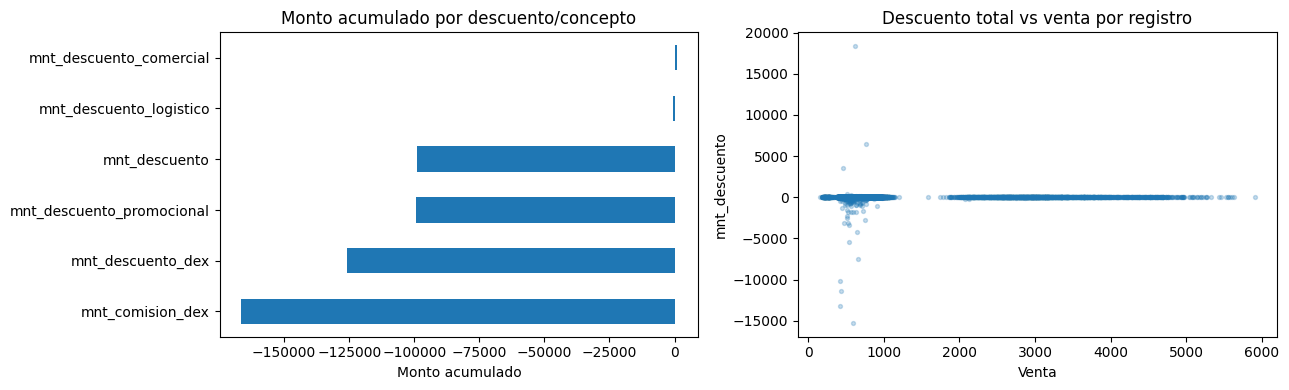

In [98]:
# Grafico de descuentos y dispersion descuento total vs venta
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resumen_descuentos.sort_values("monto_acumulado").plot(
    x="variable",
    y="monto_acumulado",
    kind="barh",
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Monto acumulado por descuento/concepto")
axes[0].set_xlabel("Monto acumulado")
axes[0].set_ylabel("")

axes[1].scatter(df_ventas["venta"], df_ventas["mnt_descuento"], alpha=0.25, s=8)
axes[1].set_title("Descuento total vs venta por registro")
axes[1].set_xlabel("Venta")
axes[1].set_ylabel("mnt_descuento")

plt.tight_layout()
plt.show()


### Hallazgo relevante

El `mnt_descuento` acumulado es **-99,081.64**, equivalente a aproximadamente **-0.39%** de la venta acumulada. El `mnt_descuento_dex` suma **-125,676.70** (**-0.50%**) y `mnt_comision_dex` suma **-166,393.75** (**-0.66%**). Los descuentos y comisiones analizados tienen una participación reducida respecto al volumen total de ventas y no parecen tener la magnitud suficiente para explicar, por sí solos, una caída comercial de varios millones en 2024 y 2025.

## 24. Revisar costos/gastos vs ventas

Se revisan costos y gastos asociados al registro para identificar los conceptos con mayor peso relativo frente a la venta acumulada.

In [99]:
# Resumen de costos y gastos frente a ventas
columnas_costos_gastos = [
    "mnt_costo_venta",
    "mnt_desmedro",
    "mnt_comision",
    "mnt_gasto_venta",
    "mnt_ppim",
    "mnt_go_to_market",
    "mnt_asesoria_tecnica",
    "mnt_ppim_trade",
    "mnt_cost_to_serve",
]

resumen_costos_gastos = pd.DataFrame({
    "variable": columnas_costos_gastos,
    "monto_acumulado": [df_ventas[col].sum() for col in columnas_costos_gastos],
    "registros_con_monto": [(df_ventas[col] != 0).sum() for col in columnas_costos_gastos],
    "participacion_sobre_venta_pct": [df_ventas[col].sum() / df_ventas["venta"].sum() * 100 for col in columnas_costos_gastos],
    "correlacion_con_venta": [df_ventas[[col, "venta"]].corr().iloc[0, 1] for col in columnas_costos_gastos],
})

resumen_costos_gastos["monto_abs"] = resumen_costos_gastos["monto_acumulado"].abs()
resumen_costos_gastos.sort_values("monto_abs", ascending=False)


,variable,monto_acumulado,registros_con_monto,participacion_sobre_venta_pct,correlacion_con_venta,monto_abs
0,mnt_costo_venta,3680757.54,2641,14.52,0.00,3680757.54
5,mnt_go_to_market,-1822317.48,158,-7.19,0.01,1822317.48
8,mnt_cost_to_serve,-365845.78,7791,-1.44,0.01,365845.78
3,mnt_gasto_venta,-25794.50,8236,-0.10,0.02,25794.50
4,mnt_ppim,-4355.59,16,-0.02,-0.00,4355.59
7,mnt_ppim_trade,-1382.57,10,-0.01,0.00,1382.57
1,mnt_desmedro,-291.08,201,-0.00,0.01,291.08
2,mnt_comision,17.20,21,0.00,-0.00,17.20
6,mnt_asesoria_tecnica,-4.66,56,-0.00,0.00,4.66


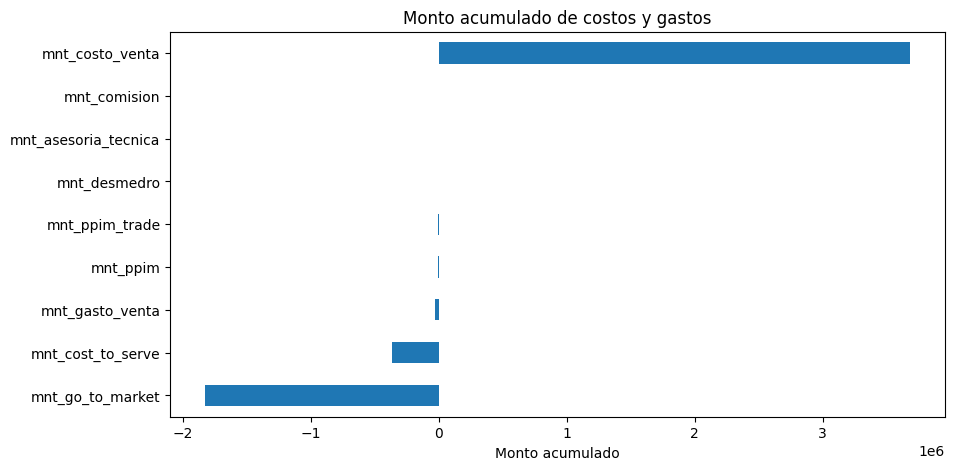

In [100]:
# Grafico de costos/gastos acumulados
fig, ax = plt.subplots(figsize=(10, 5))
resumen_costos_gastos.sort_values("monto_acumulado").plot(
    x="variable",
    y="monto_acumulado",
    kind="barh",
    ax=ax,
    legend=False,
)
ax.set_title("Monto acumulado de costos y gastos")
ax.set_xlabel("Monto acumulado")
ax.set_ylabel("")
plt.show()


### Hallazgo relevante

El concepto con mayor peso es `mnt_costo_venta`, con **3,680,757.54**, equivalente a **14.52%** de la venta acumulada. Entre los gastos o ajustes negativos destacan `mnt_go_to_market`, con **-1,822,317.48** (**-7.19%**), y `mnt_cost_to_serve`, con **-365,845.78** (**-1.44%**). Estos conceptos son relevantes para un analisis de rentabilidad o margen, pero deben interpretarse con cuidado porque el signo contable depende de la convencion usada en la base de datos.

## 25. Seleccion de familia para analisis profundo

Se combinan los criterios de participacion en venta, caida anual, cantidad de registros, clientes y productos/SKUs para seleccionar una familia prioritaria de analisis.

In [101]:
# Criterios para seleccionar familia de analisis profundo
criterios_familia = (
    ventas_familia_anio
    .reset_index()
    .merge(
        ventas_por_familia[[
            "des_familia",
            "venta_acumulada",
            "participacion_venta_pct",
            "registros",
            "clientes_unicos",
            "materiales_unicos",
        ]],
        on="des_familia",
        how="left",
    )
)

criterios_familia = criterios_familia.sort_values(
    ["participacion_venta_pct", "variacion_2025_vs_2024_abs"],
    ascending=[False, True],
)

criterios_familia


,des_familia,2024,2025,venta_acumulada_x,variacion_2025_vs_2024_abs,variacion_2025_vs_2024_pct,venta_acumulada_y,participacion_venta_pct,registros,clientes_unicos,materiales_unicos
5,Frescura,6597480.45,3518432.77,10115913.22,-3079047.68,-46.67,10115913.22,39.92,14063,83,15
4,Delicada,3828283.46,2405141.06,6233424.52,-1423142.40,-37.17,6233424.52,24.60,8625,82,14
3,Cuidado,2895336.60,2656345.07,5551681.67,-238991.53,-8.25,5551681.67,21.91,8305,76,9
6,Original,1026210.85,519007.94,1545218.79,-507202.91,-49.42,1545218.79,6.10,2076,118,33
0,Activa,1469512.65,8325.15,1477837.80,-1461187.50,-99.43,1477837.80,5.83,1664,57,9
1,Avance,216841.97,23076.82,239918.79,-193765.15,-89.36,239918.79,0.95,296,39,12
7,Vital,164874.78,1692.87,166567.65,-163181.91,-98.97,166567.65,0.66,213,33,5
2,Confort,12450.71,0.00,12450.71,-12450.71,-100.00,12450.71,0.05,17,14,1


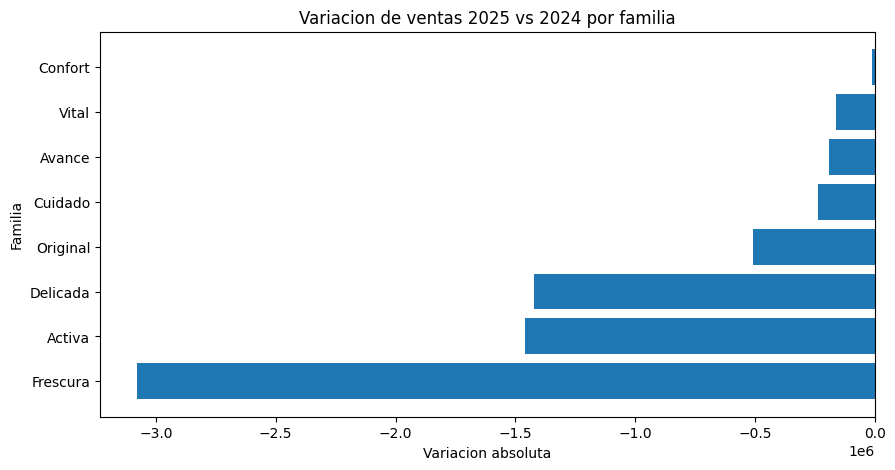

In [102]:
# Grafico de variacion anual por familia
familias_variacion = criterios_familia.sort_values("variacion_2025_vs_2024_abs")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(familias_variacion["des_familia"], familias_variacion["variacion_2025_vs_2024_abs"])
ax.set_title("Variacion de ventas 2025 vs 2024 por familia")
ax.set_xlabel("Variacion absoluta")
ax.set_ylabel("Familia")
plt.show()


### Familia seleccionada

La familia prioritaria para analisis profundo es `Frescura`. Es la familia con mayor venta acumulada (**10,115,913.22**) y mayor participacion (**39.92%**), y tambien explica la mayor caida absoluta frente a 2024 (**-3,079,047.68**). Ademas, tiene una base comercial amplia, con **14,063** registros, **83** clientes unicos y **15** productos/SKUs unicos.

Como segunda lectura, `Delicada` y `Cuidado` tambien son importantes por participacion, porque junto con `Frescura` concentran gran parte de la venta acumulada. `Activa` puede revisarse como caso puntual por su caida porcentual muy alta, pero por impacto total la prioridad comercial sigue siendo `Frescura`.

# SEGUNDA ETAPA: EDA focalizado en Frescura

Luego de seleccionar `Frescura` como familia prioritaria, se profundiza el analisis para entender mejor donde se origina la caida: tiempo, zona, cliente, SKU/material, grupo de precio, lista de precio y descuentos principales.

In [103]:
# Crear base especifica para Frescura
df_frescura = df_ventas[df_ventas["des_familia"].eq("Frescura")].copy()
df_frescura["anio"] = df_frescura["periodo"].dt.year

resumen_frescura = pd.DataFrame({
    "indicador": [
        "venta_acumulada",
        "registros",
        "clientes_unicos",
        "materiales_unicos",
        "venta_promedio_por_registro",
    ],
    "valor": [
        df_frescura["venta"].sum(),
        len(df_frescura),
        df_frescura["cod_cliente"].nunique(),
        df_frescura["cod_material"].nunique(),
        df_frescura["venta"].mean(),
    ],
})

resumen_frescura


,indicador,valor
0,venta_acumulada,10115913.22
1,registros,14063.00
2,clientes_unicos,83.00
3,materiales_unicos,15.00
4,venta_promedio_por_registro,719.33


### Hallazgo base

`Frescura` acumula **10,115,913.22** en ventas, con **14,063** registros, **83** clientes unicos y **15** productos/SKUs unicos. Por su peso comercial y por explicar la mayor caida absoluta entre 2024 y 2025, se toma como familia prioritaria para el analisis profundo.

## 1. Evolucion mensual de Frescura

Se revisa la evolucion mensual para identificar si la caida fue gradual o si se concentra en meses especificos.

In [104]:
# Evolucion mensual de Frescura
frescura_mensual = (
    df_frescura
    .groupby("periodo", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        registros=("venta", "size"),
        venta_promedio_por_registro=("venta", "mean"),
        clientes_unicos=("cod_cliente", "nunique"),
        materiales_unicos=("cod_material", "nunique"),
    )
)

frescura_mensual["variacion_mensual_abs"] = frescura_mensual["venta_acumulada"].diff()
frescura_mensual["variacion_mensual_pct"] = frescura_mensual["venta_acumulada"].pct_change() * 100

frescura_mensual


,periodo,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,variacion_mensual_abs,variacion_mensual_pct
0,2024-01-01,323277.15,417,775.24,52,7,NaN,NaN
1,2024-02-01,529482.39,646,819.63,51,6,206205.24,63.79
2,2024-03-01,544582.04,735,740.93,49,6,15099.65,2.85
3,2024-04-01,755865.93,652,1159.30,51,7,211283.89,38.80
4,2024-05-01,631038.84,626,1008.05,49,10,-124827.09,-16.51
5,2024-06-01,940523.30,1148,819.27,52,10,309484.46,49.04
6,2024-07-01,751871.93,975,771.15,59,10,-188651.37,-20.06
7,2024-08-01,231868.42,318,729.15,48,12,-520003.51,-69.16
8,2024-09-01,954784.69,1371,696.41,56,10,722916.27,311.78
9,2024-10-01,291551.18,449,649.33,50,11,-663233.51,-69.46


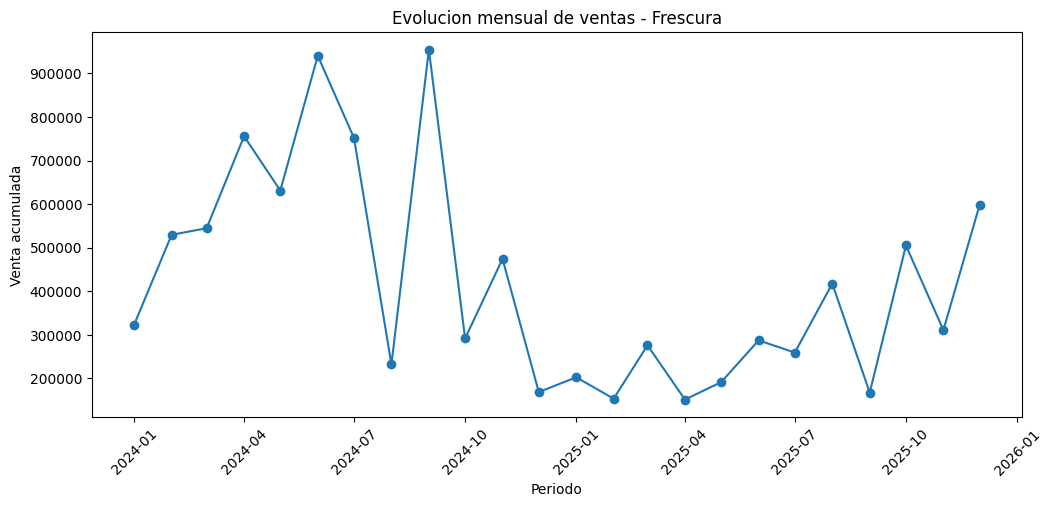

In [105]:
# Grafico de evolucion mensual de Frescura
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(frescura_mensual["periodo"], frescura_mensual["venta_acumulada"], marker="o")
ax.set_title("Evolucion mensual de ventas - Frescura")
ax.set_xlabel("Periodo")
ax.set_ylabel("Venta acumulada")
plt.xticks(rotation=45)
plt.show()


### Hallazgo relevante

La caida de `Frescura` no fue completamente gradual; el comportamiento mensual es volatil. La venta pasa de **6,597,480.45** en 2024 a **3,518,432.77** en 2025, una caida de **-3,079,047.68** (**-46.67%**). El mayor pico ocurre en **septiembre de 2024** con **954,784.69**, mientras que el menor mes es **abril de 2025** con **151,181.64**. La caida mensual mas fuerte ocurre de septiembre a octubre de 2024, con **-663,233.51** (**-69.46%**), por lo que el problema no aparece solo al inicio de 2025, sino que ya se observan quiebres importantes desde el cierre de 2024.

## 2. Ventas de Frescura por zona

Se revisa si las zonas que lideran la venta general tambien explican el comportamiento de `Frescura`, y que zonas explican la caida entre 2024 y 2025.

In [106]:
# Ventas de Frescura por zona
frescura_zona = (
    df_frescura
    .groupby("des_zona_venta", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        venta_promedio_por_registro=("venta", "mean"),
        registros=("venta", "size"),
        clientes_unicos=("cod_cliente", "nunique"),
        materiales_unicos=("cod_material", "nunique"),
    )
)

frescura_zona["participacion_venta_pct"] = frescura_zona["venta_acumulada"] / df_frescura["venta"].sum() * 100
frescura_zona.sort_values("venta_acumulada", ascending=False).head(15)


,des_zona_venta,venta_acumulada,venta_promedio_por_registro,registros,clientes_unicos,materiales_unicos,participacion_venta_pct
8,CUSCO,1560370.44,1470.66,1061,8,10,15.42
15,LIMA,1404881.11,631.69,2224,16,12,13.89
5,CHICLAYO,619006.54,836.50,740,8,11,6.12
2,AREQUIPA,608438.31,612.11,994,7,11,6.01
22,TARAPOTO,567625.88,698.19,813,3,10,5.61
11,HUANUCO,516304.28,915.43,564,3,10,5.10
21,TACNA,507618.47,646.65,785,5,10,5.02
24,TRUJILLO,464969.13,872.36,533,5,11,4.60
23,TARMA,444292.06,577.00,770,5,11,4.39
4,CAJAMARCA,366541.95,662.82,553,3,10,3.62


In [107]:
# Variacion 2024 vs 2025 por zona en Frescura
frescura_zona_anio = (
    df_frescura
    .pivot_table(
        index="des_zona_venta",
        columns="anio",
        values="venta",
        aggfunc="sum",
        fill_value=0,
    )
)

frescura_zona_anio["variacion_2025_vs_2024_abs"] = frescura_zona_anio.get(2025, 0) - frescura_zona_anio.get(2024, 0)
frescura_zona_anio["variacion_2025_vs_2024_pct"] = (
    frescura_zona_anio["variacion_2025_vs_2024_abs"] / frescura_zona_anio.get(2024, 0).replace(0, np.nan) * 100
)

frescura_zona_anio.sort_values("variacion_2025_vs_2024_abs").head(15)


anio,2024,2025,variacion_2025_vs_2024_abs,variacion_2025_vs_2024_pct
des_zona_venta,,,,
CUSCO,1252340.35,308030.09,-944310.26,-75.40
LIMA,886252.34,518628.77,-367623.57,-41.48
HUANUCO,416426.31,99877.97,-316548.34,-76.02
TRUJILLO,370492.98,94476.15,-276016.83,-74.50
CHICLAYO,413639.86,205366.68,-208273.18,-50.35
PIURA,214369.38,58727.59,-155641.79,-72.60
AREQUIPA,368045.90,240392.41,-127653.49,-34.68
TARAPOTO,338392.51,229233.37,-109159.14,-32.26
ICA,157676.34,95362.13,-62314.21,-39.52


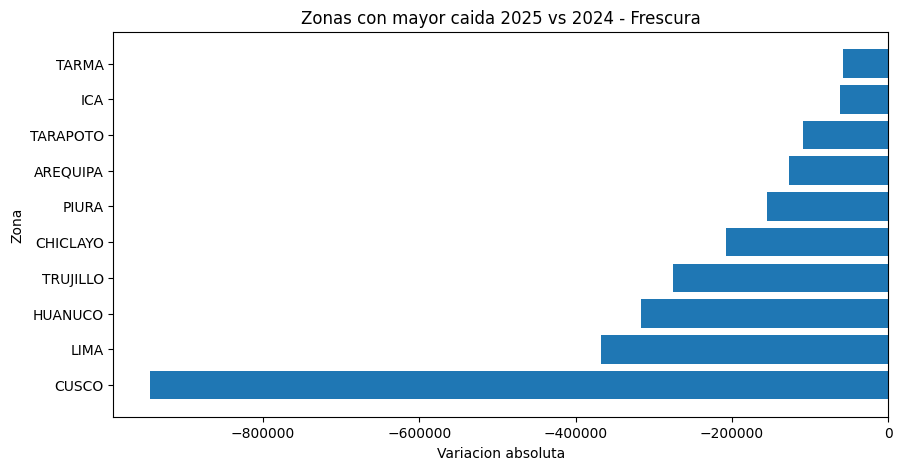

In [108]:
# Grafico de zonas con mayor caida en Frescura
zonas_caida_frescura = frescura_zona_anio.sort_values("variacion_2025_vs_2024_abs").head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(zonas_caida_frescura["des_zona_venta"], zonas_caida_frescura["variacion_2025_vs_2024_abs"])
ax.set_title("Zonas con mayor caida 2025 vs 2024 - Frescura")
ax.set_xlabel("Variacion absoluta")
ax.set_ylabel("Zona")
plt.show()


### Hallazgo relevante

Dentro de `Frescura`, `CUSCO` y `LIMA` tambien son las zonas de mayor venta, con **15.42%** y **13.89%** de participacion respectivamente. Sin embargo, la caida no se distribuye de forma uniforme: `CUSCO` explica la mayor reduccion absoluta, con **-944,310.26** frente a 2024, seguida por `LIMA` (**-367,623.57**), `HUANUCO` (**-316,548.34**) y `TRUJILLO` (**-276,016.83**). Esto indica que la problematica de Frescura tiene un componente geografico importante, especialmente en `CUSCO`.

## 3. Ventas por cliente dentro de Frescura

Se revisan los clientes con mayor peso dentro de la familia y los clientes que redujeron mas su compra entre 2024 y 2025.

In [109]:
# Clientes principales dentro de Frescura
frescura_cliente = (
    df_frescura
    .groupby("cod_cliente", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        venta_promedio_por_registro=("venta", "mean"),
        registros=("venta", "size"),
        zonas_unicas=("des_zona_venta", "nunique"),
        materiales_unicos=("cod_material", "nunique"),
    )
)

frescura_cliente["participacion_venta_pct"] = frescura_cliente["venta_acumulada"] / df_frescura["venta"].sum() * 100
frescura_cliente.sort_values("venta_acumulada", ascending=False).head(10)


,cod_cliente,venta_acumulada,venta_promedio_por_registro,registros,zonas_unicas,materiales_unicos,participacion_venta_pct
45,1000009492,676670.66,3300.83,205,2,10,6.69
16,1000005292,464517.96,3225.82,144,2,9,4.59
43,1000009451,296510.53,678.51,437,2,9,2.93
36,1000009332,295519.46,710.38,416,2,10,2.92
27,1000009045,271099.42,721.01,376,1,10,2.68
46,1000009493,267228.72,618.58,432,3,10,2.64
28,1000009052,263066.72,2989.39,88,1,6,2.60
55,1000009572,252557.59,531.70,475,1,9,2.50
39,1000009385,247764.49,648.60,382,2,9,2.45
51,1000009557,247459.69,563.69,439,1,11,2.45


In [110]:
# Clientes que mas redujeron ventas en Frescura
frescura_cliente_anio = (
    df_frescura
    .pivot_table(
        index="cod_cliente",
        columns="anio",
        values="venta",
        aggfunc="sum",
        fill_value=0,
    )
)

frescura_cliente_anio["variacion_2025_vs_2024_abs"] = frescura_cliente_anio.get(2025, 0) - frescura_cliente_anio.get(2024, 0)
frescura_cliente_anio["variacion_2025_vs_2024_pct"] = (
    frescura_cliente_anio["variacion_2025_vs_2024_abs"] / frescura_cliente_anio.get(2024, 0).replace(0, np.nan) * 100
)
frescura_cliente_anio["estado"] = np.select(
    [
        (frescura_cliente_anio.get(2024, 0) > 0) & (frescura_cliente_anio.get(2025, 0) == 0),
        (frescura_cliente_anio.get(2024, 0) == 0) & (frescura_cliente_anio.get(2025, 0) > 0),
    ],
    ["sin_venta_2025", "nuevo_2025"],
    default="presente_ambos",
)

frescura_cliente_anio.sort_values("variacion_2025_vs_2024_abs").head(15)


anio,2024,2025,variacion_2025_vs_2024_abs,variacion_2025_vs_2024_pct,estado
cod_cliente,,,,,
1000005292,464517.96,0.00,-464517.96,-100.00,sin_venta_2025
1000009492,545333.27,131337.39,-413995.88,-75.92,presente_ambos
1000009052,263066.72,0.00,-263066.72,-100.00,sin_venta_2025
1000009561,225960.05,0.00,-225960.05,-100.00,sin_venta_2025
1000005273,216577.02,0.00,-216577.02,-100.00,sin_venta_2025
1000009406,162909.89,36557.53,-126352.36,-77.56,presente_ambos
1000009328,128839.68,6830.66,-122009.02,-94.70,presente_ambos
1000001633,126938.09,9696.81,-117241.28,-92.36,presente_ambos
1000009607,113994.52,0.00,-113994.52,-100.00,sin_venta_2025


In [111]:
# Resumen de clientes perdidos/nuevos en Frescura
resumen_clientes_frescura = pd.DataFrame({
    "indicador": [
        "clientes_con_venta_2024",
        "clientes_con_venta_2025",
        "clientes_sin_venta_2025",
        "clientes_nuevos_2025",
    ],
    "valor": [
        (frescura_cliente_anio.get(2024, 0) > 0).sum(),
        (frescura_cliente_anio.get(2025, 0) > 0).sum(),
        (frescura_cliente_anio["estado"] == "sin_venta_2025").sum(),
        (frescura_cliente_anio["estado"] == "nuevo_2025").sum(),
    ],
})

resumen_clientes_frescura


,indicador,valor
0,clientes_con_venta_2024,71
1,clientes_con_venta_2025,61
2,clientes_sin_venta_2025,22
3,clientes_nuevos_2025,12


### Hallazgo relevante

El cliente con mayor venta dentro de `Frescura` es `1000009492`, con **676,670.66** y **6.69%** de la venta de la familia. La caida por cliente es relevante: los clientes con venta pasan de **71** en 2024 a **61** en 2025. Ademas, **22** clientes con venta en 2024 no registran venta en 2025, mientras que aparecen **12** clientes nuevos en 2025. Entre las reducciones mas fuertes destacan `1000005292` (**-464,517.96**), `1000009492` (**-413,995.88**) y `1000009052` (**-263,066.72**). Esto sugiere que la caida de Frescura no solo es de ticket promedio, sino tambien de perdida o reduccion fuerte de clientes especificos.

## 4. Ventas por SKU dentro de Frescura

Se revisa si la caida se concentra en uno o pocos productos/SKUs, o si esta repartida en toda la familia.

In [112]:
# Ventas por SKU/material dentro de Frescura
frescura_sku = (
    df_frescura
    .groupby("cod_material", as_index=False)
    .agg(
        venta_acumulada=("venta", "sum"),
        venta_promedio_por_registro=("venta", "mean"),
        registros=("venta", "size"),
        clientes_unicos=("cod_cliente", "nunique"),
        zonas_unicas=("des_zona_venta", "nunique"),
    )
)

frescura_sku["participacion_venta_pct"] = frescura_sku["venta_acumulada"] / df_frescura["venta"].sum() * 100
frescura_sku.sort_values("venta_acumulada", ascending=False)


,cod_material,venta_acumulada,venta_promedio_por_registro,registros,clientes_unicos,zonas_unicas,participacion_venta_pct
10,SKU_0060,2638362.57,660.25,3996,72,26,26.08
11,SKU_0061,1626719.12,659.93,2465,68,26,16.08
9,SKU_0055,1305672.02,693.77,1882,57,23,12.91
5,SKU_0026,1247823.39,871.39,1432,54,25,12.34
8,SKU_0054,1239897.23,678.28,1828,53,23,12.26
4,SKU_0025,633383.07,825.79,767,52,23,6.26
2,SKU_0021,469237.47,774.32,606,50,25,4.64
7,SKU_0028,456690.22,878.25,520,37,19,4.51
6,SKU_0027,392556.46,809.39,485,41,22,3.88
14,SKU_0087,90905.13,1594.83,57,27,19,0.90


In [113]:
# Variacion 2024 vs 2025 por SKU/material en Frescura
frescura_sku_anio = (
    df_frescura
    .pivot_table(
        index="cod_material",
        columns="anio",
        values="venta",
        aggfunc="sum",
        fill_value=0,
    )
)

frescura_sku_anio["variacion_2025_vs_2024_abs"] = frescura_sku_anio.get(2025, 0) - frescura_sku_anio.get(2024, 0)
frescura_sku_anio["variacion_2025_vs_2024_pct"] = (
    frescura_sku_anio["variacion_2025_vs_2024_abs"] / frescura_sku_anio.get(2024, 0).replace(0, np.nan) * 100
)

frescura_sku_anio.sort_values("variacion_2025_vs_2024_abs")


anio,2024,2025,variacion_2025_vs_2024_abs,variacion_2025_vs_2024_pct
cod_material,,,,
SKU_0026,1240474.30,7349.09,-1233125.21,-99.41
SKU_0025,630257.63,3125.44,-627132.19,-99.50
SKU_0021,466846.37,2391.10,-464455.27,-99.49
SKU_0028,440167.47,16522.75,-423644.72,-96.25
SKU_0027,367723.61,24832.85,-342890.76,-93.25
SKU_0087,89338.48,1566.65,-87771.83,-98.25
SKU_0060,1337704.07,1300658.50,-37045.57,-2.77
SKU_0061,818989.20,807729.92,-11259.28,-1.37
SKU_0022,1289.10,0.00,-1289.10,-100.00


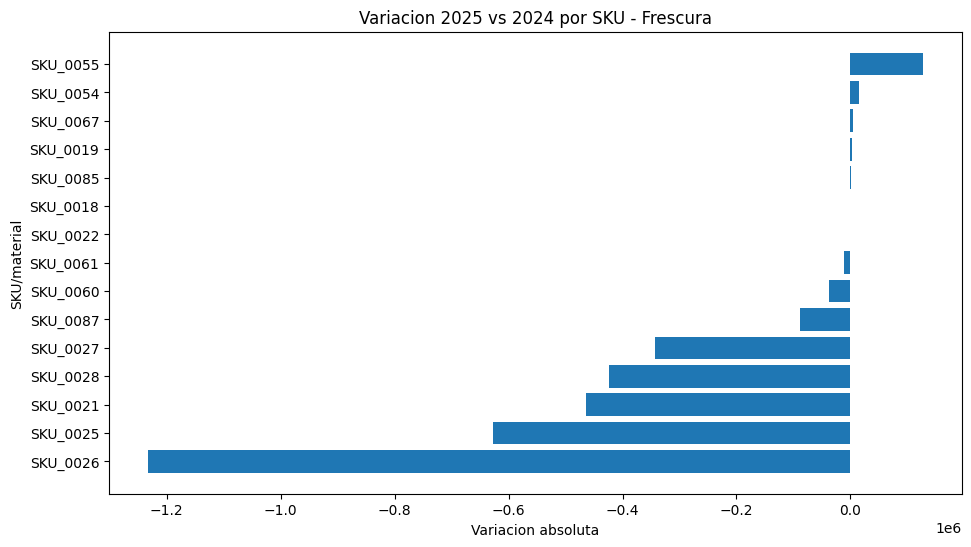

In [114]:
# Grafico de variacion por SKU/material en Frescura
sku_variacion_frescura = frescura_sku_anio.sort_values("variacion_2025_vs_2024_abs").reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(sku_variacion_frescura["cod_material"], sku_variacion_frescura["variacion_2025_vs_2024_abs"])
ax.set_title("Variacion 2025 vs 2024 por SKU - Frescura")
ax.set_xlabel("Variacion absoluta")
ax.set_ylabel("SKU/material")
plt.show()


### Hallazgo relevante

La venta de `Frescura` se concentra en pocos SKUs: `SKU_0060` representa **26.08%** de la venta de la familia y `SKU_0061` representa **16.08%**. Sin embargo, la mayor caida no viene de esos dos SKUs principales, sino de otros productos: `SKU_0026` cae **-1,233,125.21**, `SKU_0025` cae **-627,132.19** y `SKU_0021` cae **-464,455.27**. Esto sugiere que la caida de Frescura no esta concentrada unicamente en el SKU lider, sino en varios SKUs que practicamente desaparecen o reducen fuertemente su venta en 2025.

## 5. Grupo de precio y lista de precio dentro de Frescura

Se valida si los patrones encontrados a nivel general tambien se mantienen dentro de la familia seleccionada.

In [115]:
# Grupo de precio dentro de Frescura
frescura_grupo_precio = resumir_ventas_por_dimension(df_frescura, "cod_grupo_precio", top=10)
frescura_grupo_precio


,cod_grupo_precio,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
0,B1,7975234.59,13282,600.45,76,15,78.84,78.84
1,B2,2140678.63,781,2740.95,10,10,21.16,100.00


In [116]:
# Lista de precio dentro de Frescura
frescura_lista_precio = resumir_ventas_por_dimension(df_frescura, "des_lista_precio_actual", top=10)
frescura_lista_precio


,des_lista_precio_actual,venta_acumulada,registros,venta_promedio_por_registro,clientes_unicos,materiales_unicos,participacion_venta_pct,participacion_acumulada_pct
1,Minor,8034249.12,13374,600.74,73,15,79.42,79.42
0,Mayor,2072436.12,653,3173.72,10,10,20.49,99.91
2,Sin Asignar,9227.98,36,256.33,28,6,0.09,100.00


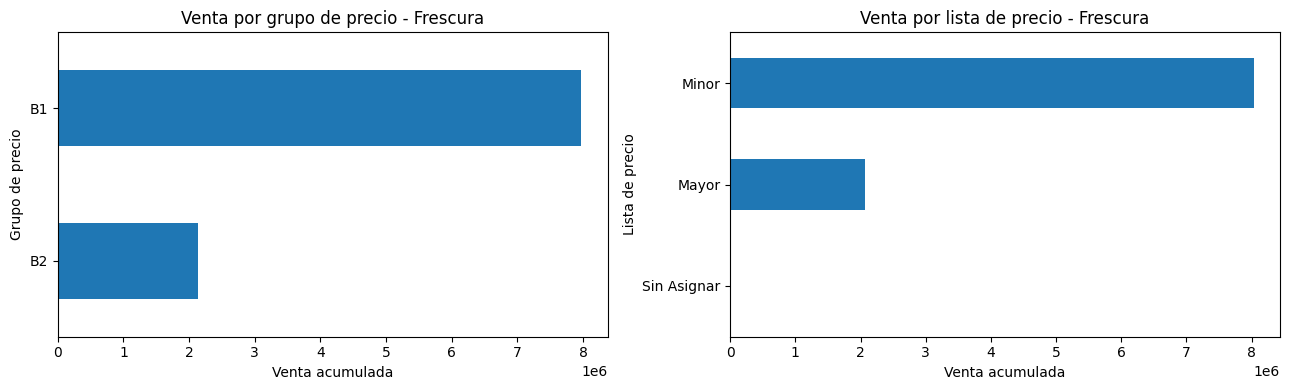

In [117]:
# Graficos de grupo de precio y lista de precio en Frescura
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

frescura_grupo_precio.sort_values("venta_acumulada").plot(
    x="cod_grupo_precio",
    y="venta_acumulada",
    kind="barh",
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Venta por grupo de precio - Frescura")
axes[0].set_xlabel("Venta acumulada")
axes[0].set_ylabel("Grupo de precio")

frescura_lista_precio.sort_values("venta_acumulada").plot(
    x="des_lista_precio_actual",
    y="venta_acumulada",
    kind="barh",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Venta por lista de precio - Frescura")
axes[1].set_xlabel("Venta acumulada")
axes[1].set_ylabel("Lista de precio")

plt.tight_layout()
plt.show()


### Hallazgo relevante

El patron general se mantiene dentro de `Frescura`: `B1` concentra **7,975,234.59** (**78.84%**) y `B2` concentra **2,140,678.63** (**21.16%**). `B2` tiene una venta promedio por registro mucho mayor (**2,740.95** frente a **600.45** en `B1`). Por lista de precio, `Minor` concentra **79.42%** de la venta de Frescura, mientras que `Mayor` concentra **20.49%** y presenta mayor venta promedio por registro (**3,173.72**). Para este EDA, `B2` y `Mayor` pueden interpretarse como segmentos analiticos de mayor valor promedio por registro, no necesariamente como categorias oficiales del ERP.

## 6. Descuentos dentro de Frescura

Se revisa si la caida de `Frescura` vino acompanada de cambios fuertes en descuentos o promociones.

In [118]:
# Correlacion entre venta y descuentos principales en Frescura
columnas_descuento_frescura = [
    "venta",
    "mnt_descuento",
    "mnt_descuento_promocional",
    "mnt_descuento_comercial",
    "mnt_descuento_logistico",
    "mnt_descuento_dex",
]

df_frescura[columnas_descuento_frescura].corr()


,venta,mnt_descuento,mnt_descuento_promocional,mnt_descuento_comercial,mnt_descuento_logistico,mnt_descuento_dex
venta,1.00,0.00,0.00,0.00,0.00,0.00
mnt_descuento,0.00,1.00,1.00,0.19,0.46,0.42
mnt_descuento_promocional,0.00,1.00,1.00,0.18,0.43,0.42
mnt_descuento_comercial,0.00,0.19,0.18,1.00,-0.02,-0.05
mnt_descuento_logistico,0.00,0.46,0.43,-0.02,1.00,0.24
mnt_descuento_dex,0.00,0.42,0.42,-0.05,0.24,1.00


In [119]:
# Descuentos principales por anio en Frescura
columnas_descuento_principales = [
    "mnt_descuento",
    "mnt_descuento_promocional",
    "mnt_descuento_comercial",
    "mnt_descuento_logistico",
    "mnt_descuento_dex",
]

frescura_descuentos_anio = (
    df_frescura
    .groupby("anio")
    .agg(
        venta_acumulada=("venta", "sum"),
        **{col: (col, "sum") for col in columnas_descuento_principales}
    )
)

for col in columnas_descuento_principales:
    frescura_descuentos_anio[f"{col}_pct_venta"] = frescura_descuentos_anio[col] / frescura_descuentos_anio["venta_acumulada"] * 100

frescura_descuentos_anio


,venta_acumulada,mnt_descuento,mnt_descuento_promocional,mnt_descuento_comercial,mnt_descuento_logistico,mnt_descuento_dex,mnt_descuento_pct_venta,mnt_descuento_promocional_pct_venta,mnt_descuento_comercial_pct_venta,mnt_descuento_logistico_pct_venta,mnt_descuento_dex_pct_venta
anio,,,,,,,,,,,
2024,6597480.45,-10435.71,-10146.32,-17.43,-271.96,-13802.30,-0.16,-0.15,-0.00,-0.00,-0.21
2025,3518432.77,-2361.54,-2372.70,2.81,8.35,-2607.14,-0.07,-0.07,0.00,0.00,-0.07


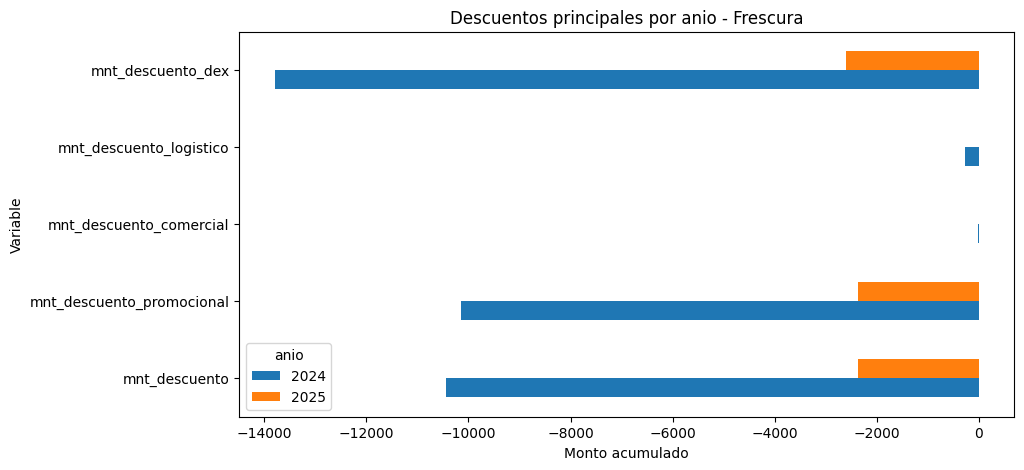

In [120]:
# Grafico de descuentos principales por anio en Frescura
frescura_descuentos_plot = frescura_descuentos_anio[columnas_descuento_principales].T

fig, ax = plt.subplots(figsize=(10, 5))
frescura_descuentos_plot.plot(kind="barh", ax=ax)
ax.set_title("Descuentos principales por anio - Frescura")
ax.set_xlabel("Monto acumulado")
ax.set_ylabel("Variable")
plt.show()


### Hallazgo relevante

En `Frescura`, los descuentos tienen un peso bajo frente a la venta. El `mnt_descuento` pasa de **-10,435.71** en 2024 a **-2,361.54** en 2025, y su peso sobre ventas baja de **-0.16%** a **-0.07%**. La correlacion entre `venta` y los descuentos principales es cercana a cero, por lo que los descuentos no aparecen como explicacion fuerte de la caida. Mas bien, la caida parece estar asociada a menor actividad por clientes, zonas y ciertos SKUs especificos.

## Cierre del EDA 
El análisis permitió identificar una caída relevante de ventas entre 2024 y 2025, concentrada principalmente en la familia Frescura, que además representa la mayor participación dentro de la base. La reducción no parece estar explicada por los descuentos, sino por una menor actividad comercial en determinadas zonas, distribuidoras y productos específicos. Por ello, Frescura se selecciona como familia prioritaria para las siguientes etapas del proyecto. A continuación, se analizarán los datasets de variables macroeconómicas y campañas para complementar la comprensión del problema e integrarlos posteriormente en una base modelable.